# Análisis de datos atípicos en precios de viviendas

Este cuaderno analiza el dataset `data/houses.csv` y responde:

1. ¿Existen datos atípicos y en qué variables?
2. ¿Qué decisión tomar con ellos?
3. ¿Qué transformación es conveniente aplicar?

Los atípicos se identifican con el método del rango intercuartílico (IQR). Se conservan los registros originales y se agrega una marca booleana para poder comparar ambos grupos sin perder información.

In [52]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

# Funciona tanto si el notebook se abre desde la carpeta del proyecto
# como si el kernel conserva otra carpeta de trabajo.
DATA_PATH = Path("data/houses.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path.cwd() / "data" / "houses.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("No se encontró data/houses.csv. Ejecuta el notebook desde la carpeta del proyecto.")
df = pd.read_csv(DATA_PATH)
df.head()

,codigo_postal,tipo,localidad,precio(mxn_peso),habitaciones,baños,area(m2)
0,21395,Fraccionamiento,Villa Toledo,4350000,3,3,172
1,21399,Fraccionamiento,Nuevo Mexicali,2910000,3,2,115
2,21395,Fraccionamiento,Bugambilias,380000,2,1,120
3,21384,Fraccionamiento,Valle de Puebla 2da. Sección,1250000,2,1,61
4,21323,Fraccionamiento,Residencial Barcelona II,850000,3,2,170


## 1. Exploración y calidad de los datos

In [53]:
print(f"Registros: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")
display(df.dtypes.to_frame("tipo"))
display(df.isna().sum().to_frame("valores_faltantes"))
display(df.describe(include="all").T)

Registros: 940
Variables: 7


,tipo
codigo_postal,int64
tipo,str
localidad,str
precio(mxn_peso),int64
habitaciones,int64
baños,int64
area(m2),int64


,valores_faltantes
codigo_postal,0
tipo,0
localidad,0
precio(mxn_peso),0
habitaciones,0
baños,0
area(m2),0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
codigo_postal,940.0,NaN,NaN,NaN,21318.245745,116.930981,21000.0,21254.0,21354.0,21379.25,21970.0
tipo,940,3,Fraccionamiento,657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
localidad,940,283,Privadas Campestre,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio(mxn_peso),940.0,NaN,NaN,NaN,3962253.860638,2898012.77587,123456.0,1996000.0,3325000.0,5100000.0,15650000.0
habitaciones,940.0,NaN,NaN,NaN,2.897872,0.700065,1.0,3.0,3.0,3.0,6.0
baños,940.0,NaN,NaN,NaN,1.948936,0.766407,1.0,1.0,2.0,2.0,4.0
area(m2),940.0,NaN,NaN,NaN,156.190426,85.801371,35.0,99.0,134.0,193.0,550.0


El código postal se utiliza como identificador geográfico/categórico, no como una magnitud continua. Por esa razón no se considera atípico solo porque un código aparezca pocas veces.

## 2. Detección reproducible con IQR

In [54]:
def iqr_limits(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, q1 - factor * iqr, q3 + factor * iqr

numeric_for_outliers = ["precio(mxn_peso)", "habitaciones", "baños", "area(m2)"]
summary = []
for column in numeric_for_outliers:
    q1, q3, lower, upper = iqr_limits(df[column])
    mask = (df[column] < lower) | (df[column] > upper)
    summary.append({
        "variable": column,
        "Q1": q1,
        "mediana": df[column].median(),
        "Q3": q3,
        "límite_inferior": lower,
        "límite_superior": upper,
        "atípicos": int(mask.sum()),
        "%_atípicos": mask.mean() * 100,
    })

outlier_summary = pd.DataFrame(summary)
display(outlier_summary.style.format({
    "Q1": "{:,.2f}", "mediana": "{:,.2f}", "Q3": "{:,.2f}",
    "límite_inferior": "{:,.2f}", "límite_superior": "{:,.2f}",
    "%_atípicos": "{:.2f}%"
}))

,variable,Q1,mediana,Q3,límite_inferior,límite_superior,atípicos,%_atípicos
0,precio(mxn_peso),"1,996,000.00","3,325,000.00","5,100,000.00","-2,660,000.00","9,756,000.00",52,5.53%
1,habitaciones,3.00,3.00,3.00,3.00,3.00,350,37.23%
2,baños,1.00,2.00,2.00,-0.50,3.50,34,3.62%
3,area(m2),99.00,134.00,193.00,-42.00,334.00,42,4.47%


## 3. Graficas del precio y sus atipicos

Las graficas usan millones de pesos para facilitar la lectura. El boxplot resume la distribucion; el strip plot muestra cada vivienda y resalta en rojo los precios que superan el limite superior del IQR. Los histogramas permiten observar la concentracion de precios y el efecto de una escala logaritmica.


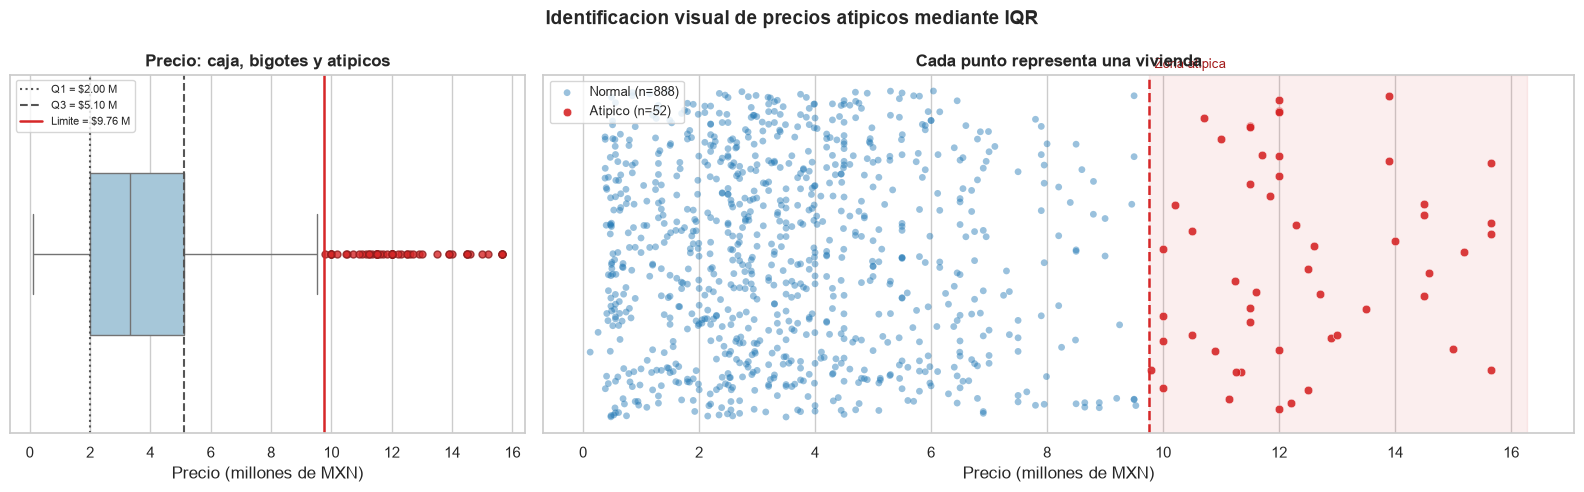

Atipicos de precio: 52 de 940 (5.53%)


In [55]:
price = "precio(mxn_peso)"
q1, q3, lower, upper = iqr_limits(df[price])
df["precio_atipico"] = (df[price] < lower) | (df[price] > upper)

# Mostrar los precios en millones hace que las escalas sean mas faciles de leer.
df["precio_millones"] = df[price] / 1_000_000
q1_m, q3_m, upper_m = q1 / 1_000_000, q3 / 1_000_000, upper / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})

sns.boxplot(
    data=df, x="precio_millones", ax=axes[0], color="#9ecae1", width=0.45,
    flierprops={"marker": "o", "markerfacecolor": "#d62728",
                "markeredgecolor": "#8c1d1d", "markersize": 5, "alpha": 0.8}
)
axes[0].axvline(q1_m, color="#555555", linestyle=":", linewidth=1.5, label=f"Q1 = ${q1_m:.2f} M")
axes[0].axvline(q3_m, color="#555555", linestyle="--", linewidth=1.5, label=f"Q3 = ${q3_m:.2f} M")
axes[0].axvline(upper_m, color="#d62728", linestyle="-", linewidth=1.8, label=f"Limite = ${upper_m:.2f} M")
axes[0].set_title("Precio: caja, bigotes y atipicos", fontweight="bold")
axes[0].set_xlabel("Precio (millones de MXN)")
axes[0].set_ylabel("")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(axis="y", visible=False)

# Strip plot: cada punto representa una vivienda; el color identifica el resultado del IQR.
rng = np.random.default_rng(42)
y = rng.uniform(-0.18, 0.18, len(df))
normal = ~df["precio_atipico"]
axes[1].scatter(df.loc[normal, "precio_millones"], y[normal], s=24, alpha=0.45,
                color="#1f77b4", edgecolors="none", label=f"Normal (n={normal.sum()})")
axes[1].scatter(df.loc[df["precio_atipico"], "precio_millones"], y[df["precio_atipico"]],
                s=38, alpha=0.9, color="#d62728", edgecolors="white", linewidth=0.4,
                label=f"Atipico (n={df['precio_atipico'].sum()})")
axes[1].axvspan(upper_m, df["precio_millones"].max() * 1.04, color="#d62728", alpha=0.08)
axes[1].axvline(upper_m, color="#d62728", linestyle="--", linewidth=1.8)
axes[1].text(upper_m + 0.1, 0.205, "Zona atipica", color="#a31a1a", fontsize=9)
axes[1].set_title("Cada punto representa una vivienda", fontweight="bold")
axes[1].set_xlabel("Precio (millones de MXN)")
axes[1].set_ylabel("")
axes[1].set_yticks([])
axes[1].legend(fontsize=9, loc="upper left")
axes[1].grid(axis="y", visible=False)

plt.suptitle("Identificacion visual de precios atipicos mediante IQR", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Atipicos de precio: {df['precio_atipico'].sum()} de {len(df)} ({df['precio_atipico'].mean():.2%})")

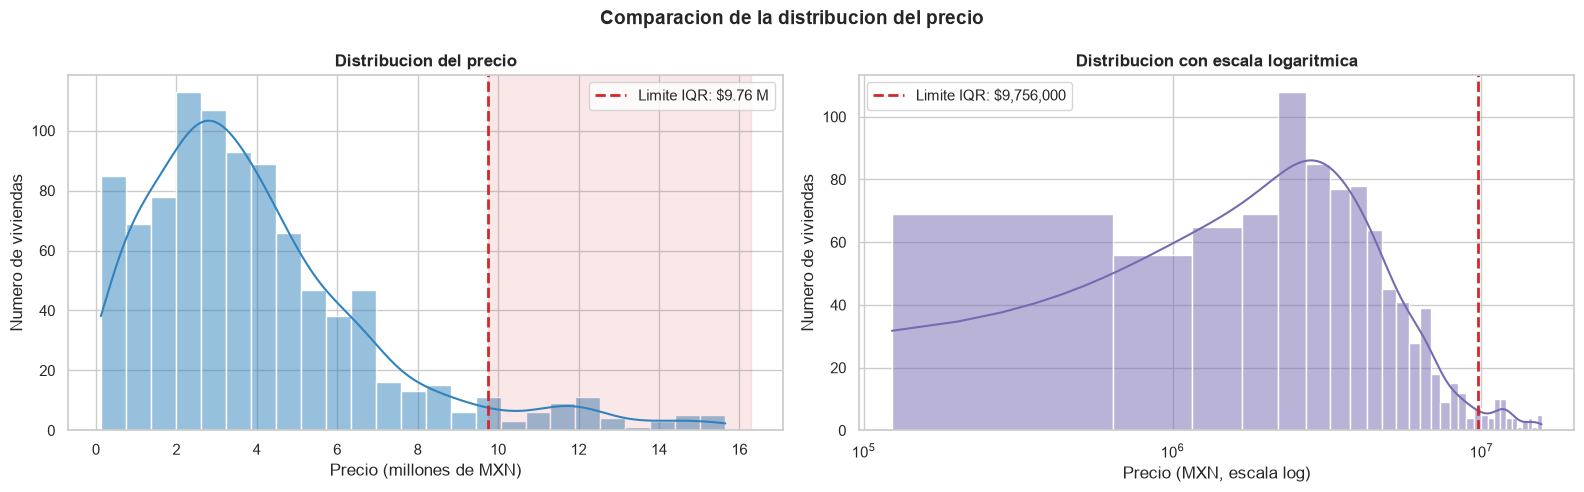

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma en escala original: permite interpretar cantidades de viviendas.
sns.histplot(data=df, x="precio_millones", bins=25, kde=True, ax=axes[0],
             color="#3182bd", edgecolor="white")
axes[0].axvline(upper_m, color="#d62728", linestyle="--", linewidth=2,
                 label=f"Limite IQR: ${upper_m:.2f} M")
axes[0].axvspan(upper_m, df["precio_millones"].max() * 1.04, color="#d62728", alpha=0.10)
axes[0].set_title("Distribucion del precio", fontweight="bold")
axes[0].set_xlabel("Precio (millones de MXN)")
axes[0].set_ylabel("Numero de viviendas")
axes[0].legend()

# La escala logaritmica permite observar mejor los precios bajos y altos al mismo tiempo.
sns.histplot(data=df, x=price, bins=30, kde=True, ax=axes[1], color="#756bb1", edgecolor="white")
axes[1].set_xscale("log")
axes[1].axvline(upper, color="#d62728", linestyle="--", linewidth=2,
                 label=f"Limite IQR: ${upper:,.0f}")
axes[1].set_title("Distribucion con escala logaritmica", fontweight="bold")
axes[1].set_xlabel("Precio (MXN, escala log)")
axes[1].set_ylabel("Numero de viviendas")
axes[1].legend()

plt.suptitle("Comparacion de la distribucion del precio", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Relación entre precio, área y atípicos

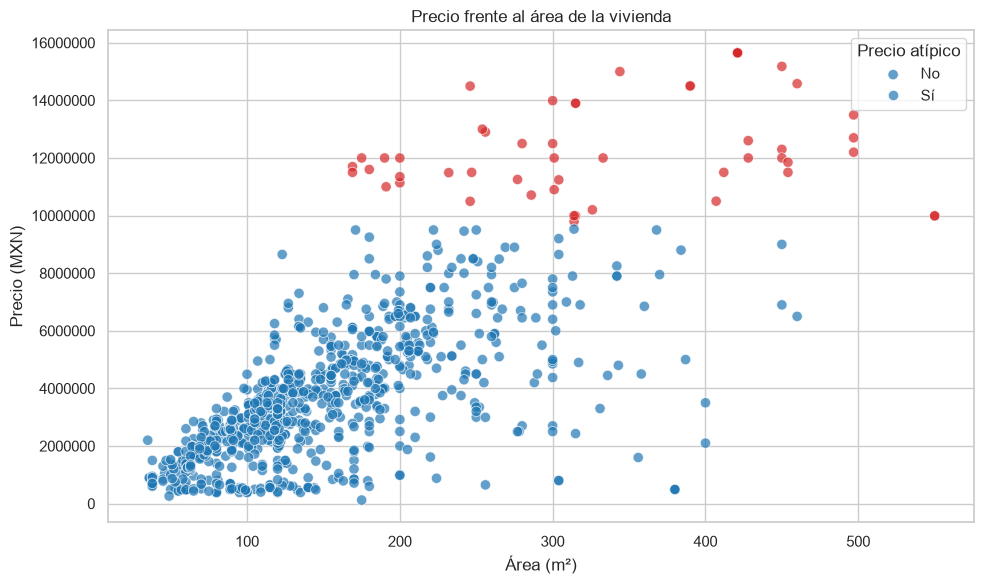

,precio(mxn_peso),area(m2),habitaciones,baños,localidad
24,15650000,421,4,4,San Pedro Residencial Segunda Sección
674,15650000,421,4,4,Cataviña
805,15650000,421,4,4,San Pedro Residencial Segunda Sección
716,15650000,421,4,4,Antea Residencial
209,15180000,450,4,3,San Pedro Residencial
535,15000000,344,3,3,San Pedro Residencial
14,14580000,460,4,3,Jardines del Valle
769,14500000,390,3,2,La Rioja
33,14500000,390,3,4,La Rioja
718,14495000,246,3,2,El Ciprés


In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="area(m2)", y=price, hue="precio_atipico",
                palette={False: "#1f77b4", True: "#d62728"}, alpha=0.7, s=55)
plt.title("Precio frente al área de la vivienda")
plt.xlabel("Área (m²)")
plt.ylabel("Precio (MXN)")
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Precio atípico", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

display(df.loc[df["precio_atipico"],
               ["precio(mxn_peso)", "area(m2)", "habitaciones", "baños", "localidad"]]
        .sort_values(price, ascending=False).head(10))

## 5. Mapas territoriales con `mxl.shp`

El mapa utiliza la geometría local `mxl.shp` proporcionada para el proyecto. Se presentan tres figuras independientes para facilitar la lectura: precio mediano, tamaño mediano de las viviendas y concentración de viviendas observadas. La segunda figura permite identificar dónde se encuentran las casas más grandes.


Polígonos de mxl.shp: 97
Polígonos con información del dataset: 73
Códigos postales usados: 73 de 88


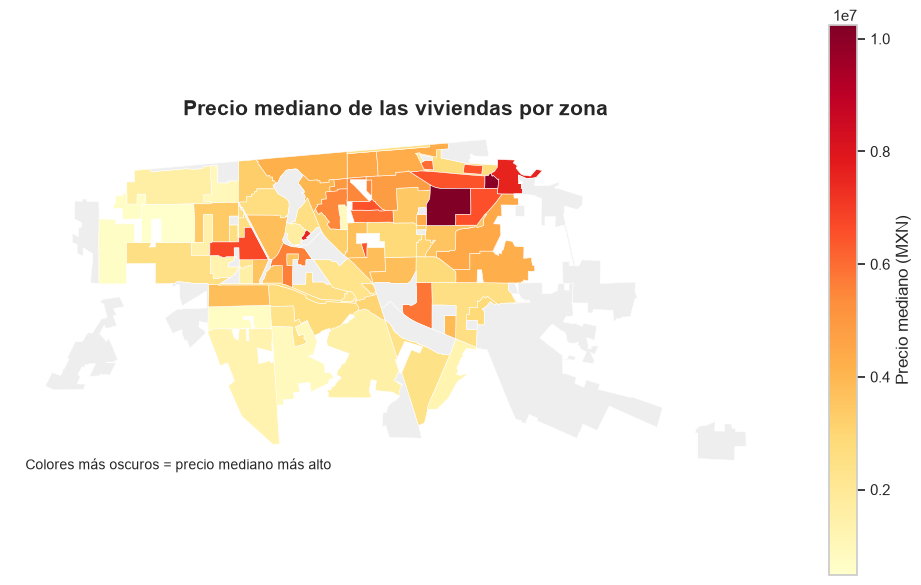

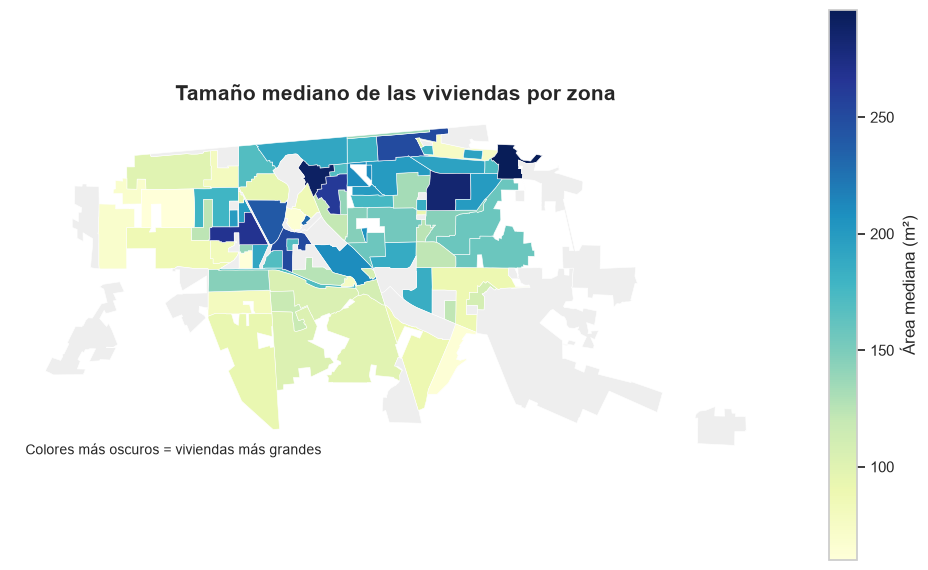

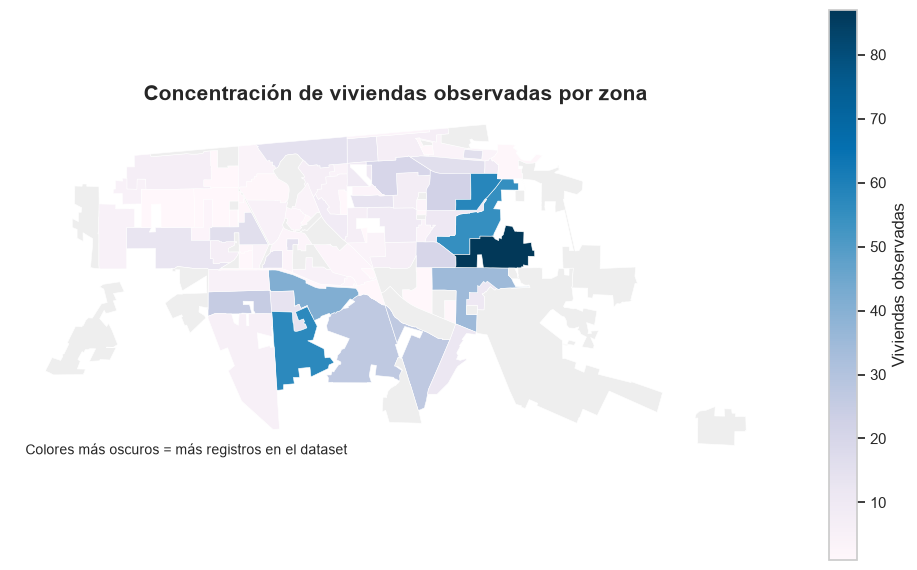

,casas_observadas,precio_mediano,area_mediana,codigos_postales
74,22.0,10245000.0,284.0,1.0
64,10.0,10000000.0,172.0,1.0
96,2.0,7600000.0,296.0,1.0
48,1.0,7500000.0,229.0,1.0
58,16.0,6725000.0,267.5,1.0
87,58.0,6575000.0,200.0,1.0
43,16.0,6500000.0,194.0,1.0
16,1.0,6500000.0,206.0,1.0
79,3.0,6495000.0,200.0,1.0
51,1.0,5980000.0,180.0,1.0


In [58]:
# Usar la geometría local de Mexicali proporcionada para el proyecto.
# El SHP llegó sin .shx/.dbf; GDAL puede reconstruir el índice .shx.
os.environ["SHAPE_RESTORE_SHX"] = "YES"
import geopandas as gpd

SHP_PATH = Path("mxl.shp")
if not SHP_PATH.exists():
    raise FileNotFoundError("No se encontró mxl.shp en la carpeta del proyecto.")

mxl_map = gpd.read_file(SHP_PATH)
if mxl_map.crs is None:
    mxl_map = mxl_map.set_crs("EPSG:4326")

# Resumir por código postal. Las medianas reducen la influencia de outliers.
by_zip = (
    df.assign(codigo_postal=df["codigo_postal"].astype(str).str.zfill(5))
      .groupby("codigo_postal")
      .agg(
          casas_observadas=("codigo_postal", "size"),
          precio_mediano=(price, "median"),
          precio_promedio=(price, "mean"),
          area_mediana=("area(m2)", "median"),
          area_promedio=("area(m2)", "mean"),
      )
      .reset_index()
)

postal_zip = gpd.read_file(Path("data/baja_california_postal.geojson"))
postal_zip["codigo_postal"] = postal_zip["d_codigo"].astype(str).str.zfill(5)
postal_zip = postal_zip.merge(by_zip, on="codigo_postal", how="inner")
postal_zip["punto_representativo"] = postal_zip.geometry.representative_point()

# Transferir los indicadores postales a la geometría principal de mxl.shp.
postal_points = postal_zip.set_geometry("punto_representativo")
postal_points = gpd.sjoin(
    postal_points[["codigo_postal", "casas_observadas", "precio_mediano", "precio_promedio", "area_mediana", "area_promedio", "punto_representativo"]],
    mxl_map[["geometry"]], how="inner", predicate="within"
)

map_stats = (
    postal_points.groupby("index_right")
    .apply(lambda group: pd.Series({
        "casas_observadas": group["casas_observadas"].sum(),
        "precio_mediano": group["precio_mediano"].median(),
        "precio_promedio": group["precio_promedio"].mean(),
        "area_mediana": group["area_mediana"].median(),
        "area_promedio": group["area_promedio"].mean(),
        "codigos_postales": group["codigo_postal"].nunique(),
    }), include_groups=False)
    .reset_index()
)
mxl_map = mxl_map.reset_index().merge(map_stats, left_on="index", right_on="index_right", how="left")

print(f"Polígonos de mxl.shp: {len(mxl_map)}")
print(f"Polígonos con información del dataset: {mxl_map['casas_observadas'].notna().sum()}")
print(f"Códigos postales usados: {postal_points['codigo_postal'].nunique()} de {by_zip['codigo_postal'].nunique()}")

# Mapa 1: precio mediano. Figura independiente para leer mejor la escala.
fig, ax = plt.subplots(figsize=(10, 8))
mxl_map.plot(
    column="precio_mediano", cmap="YlOrRd", linewidth=0.4, edgecolor="white",
    legend=True, legend_kwds={"label": "Precio mediano (MXN)", "shrink": 0.72},
    missing_kwds={"color": "#eeeeee", "label": "Sin registros"}, ax=ax
)
ax.set_title("Precio mediano de las viviendas por zona", fontsize=15, fontweight="bold")
ax.text(0.02, 0.02, "Colores más oscuros = precio mediano más alto", transform=ax.transAxes, fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

# Mapa 2: área mediana, colocado inmediatamente después del precio.
fig, ax = plt.subplots(figsize=(10, 8))
mxl_map.plot(
    column="area_mediana", cmap="YlGnBu", linewidth=0.4, edgecolor="white",
    legend=True, legend_kwds={"label": "Área mediana (m²)", "shrink": 0.72},
    missing_kwds={"color": "#eeeeee", "label": "Sin registros"}, ax=ax
)
ax.set_title("Tamaño mediano de las viviendas por zona", fontsize=15, fontweight="bold")
ax.text(0.02, 0.02, "Colores más oscuros = viviendas más grandes", transform=ax.transAxes, fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

# Mapa 3: concentración de viviendas observadas.
fig, ax = plt.subplots(figsize=(10, 8))
mxl_map.plot(
    column="casas_observadas", cmap="PuBu", linewidth=0.4, edgecolor="white",
    legend=True, legend_kwds={"label": "Viviendas observadas", "shrink": 0.72},
    missing_kwds={"color": "#eeeeee", "label": "Sin registros"}, ax=ax
)
ax.set_title("Concentración de viviendas observadas por zona", fontsize=15, fontweight="bold")
ax.text(0.02, 0.02, "Colores más oscuros = más registros en el dataset", transform=ax.transAxes, fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

display(mxl_map[["casas_observadas", "precio_mediano", "area_mediana", "codigos_postales"]]
        .sort_values("precio_mediano", ascending=False).head(10))

## 6. Decisión y transformación

Los precios atípicos no se eliminan automáticamente: pueden representar viviendas reales de lujo. Se conservarán en el dataset original y se analizarán por separado mediante `precio_atipico`. Antes de eliminarlos se debería verificar la fuente y confirmar que no sean errores de captura o de unidades.

Como el precio está sesgado a la derecha, se crea una versión logarítmica para modelos o análisis sensibles a la escala. Esta transformación no reemplaza la variable original.

In [59]:
df["precio_log"] = np.log1p(df[price])
df["area_log"] = np.log1p(df["area(m2)"])

print("Resumen final:")
print(f"- Registros conservados: {len(df):,}")
print(f"- Precios atípicos marcados: {df['precio_atipico'].sum():,}")
print("- Variables nuevas: precio_atipico, precio_log y area_log")
display(df[[price, "precio_atipico", "precio_log", "area(m2)", "area_log"]].head())

Resumen final:
- Registros conservados: 940
- Precios atípicos marcados: 52
- Variables nuevas: precio_atipico, precio_log y area_log


,precio(mxn_peso),precio_atipico,precio_log,area(m2),area_log
0,4350000,False,15.285687,172,5.153292
1,2910000,False,14.883664,115,4.753590
2,380000,False,12.847929,120,4.795791
3,1250000,False,14.038655,61,4.127134
4,850000,False,13.652993,170,5.141664
